# ***Forecasting a random walk***

Now that we know what a random walk is and how to identify one, we can start forecasting. This might sound surprising, since we established that a random walk takes random steps as time progresses.Predicting a random change is impossible, unless we predict a random value ourselves, which is not ideal. In this case, we can only use naive forecasting methods, or baselines, which we covered in baseline models. Since the values change randomly, no statistical learning model can be applied. Instead, we can only reasonably predict the historical mean, or the last value.Depending on the use case, your forecasting horizon will vary. Ideally, when dealing with a random walk, you will only forecast the next timestep.However, you may be required to forecast many timesteps into the future.Let’s look at how to tackle each of these situations.

## ***Forecasting on a long horizon***

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In this section, we’ll forecast a random walk on a long horizon. This is not an ideal case—a random walk can unexpectedly increase or decrease
because past observations are not predictive of changes in the future. Here we’ll continue working with our simulated random walk from stationarity section
To make things easier, we will assign the random walk to a DataFrame and split the dataset into train and test sets. The train set will contain the first 800 timesteps, which corresponds to 80% of the simulated data. The test set will thus contain the last 200 values:

In [31]:
np.random.seed(42)                            
steps = np.random.standard_normal(1000)       
steps[0]=0                                    
random_walk = np.cumsum(steps) 

In [32]:
df = pd.DataFrame({'value': random_walk})    
train = df[:800]                             
test = df[800:]

### ***PLOTTINING THE GRAPH***

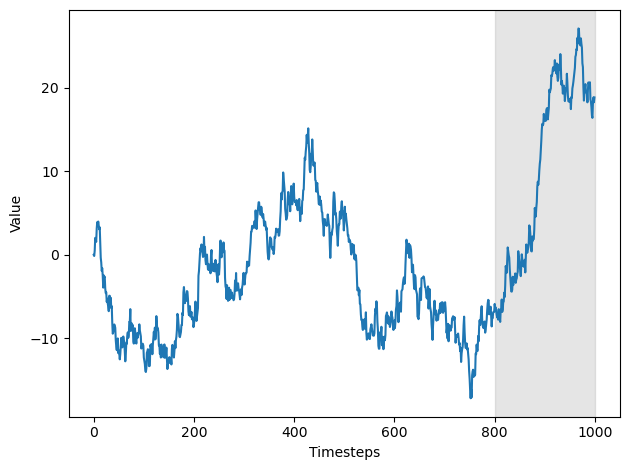

In [33]:
fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color='#808080', alpha=0.2)

plt.tight_layout()

The train/test split of our generated random walk. The first
800 timesteps are part of the train set, and the remaining values are part
of the test set. Our goal is to forecast the values in the shaded area.

### ***HISTORICAL MEAN,LAST KNOWN VALUE,DRIFT NETHOD FORCASTING***

### *HISTORICAL MEAN*

In [34]:
mean = np.mean(train.value)        
test.loc[:, 'pred_mean'] = mean    
test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


### *LAST KNOWN VALUE*

In [35]:
last_value = train.iloc[-1].value        
test.loc[:, 'pred_last'] = last_value    
test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


### *DRIFT METHOD*

Finally, we’ll apply the drift method, which we have not covered yet. The drift method is a modification of predicting the last known value. In this case, we allow the values to increase or decrease over time. The rate at which values will change in the future is equal to that seen in the train set.Therefore, it is equivalent to calculating the slope between the first and last value of the train set and simply extrapolating this straight line into the
future. Remember that we can calculate the slope of a straight line by dividing the change in the y-axis by the change in the x-axis. In our case, the change in the y-axis is the difference between the last value of our random walk yf and its initial value yi. Then, the change in the x-axis is equivalent to the number of timesteps minus 1.

In [38]:

deltaX = 800 - 1
deltaY = last_value - 0

drift = deltaY / deltaX

x_vals = np.arange(801, 1001, 1)

pred_drift = drift * x_vals

test.loc[:, 'pred_drift'] = pred_drift

test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


## ***PLOTTING ALL THE DATA***

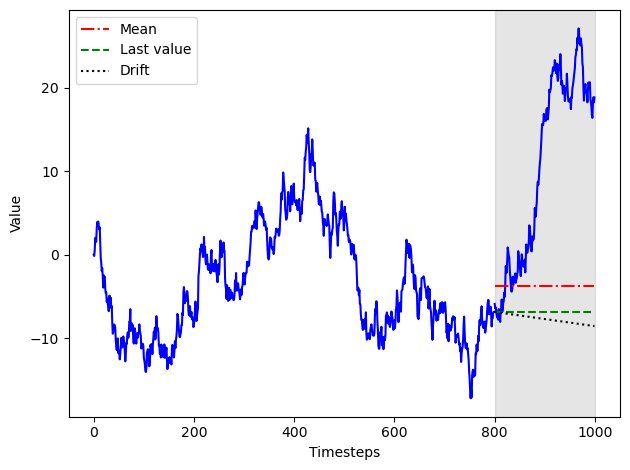

In [39]:
fig, ax = plt.subplots() 
ax.plot(train.value, 'b-')                                
ax.plot(test['value'], 'b-')                              
ax.plot(test['pred_mean'], 'r-.', label='Mean')           
ax.plot(test['pred_last'], 'g--', label='Last value')     
ax.plot(test['pred_drift'], 'k:', label='Drift')          
ax.axvspan(800, 1000, color='#808080', alpha=0.2)         
ax.legend(loc=2)                                          
ax.set_xlabel('Timesteps') 
ax.set_ylabel('Value') 
plt.tight_layout()

## **Forecasting our random walk using the mean, last known value, and drift methods. As you can see, all predictions are fairly poor and fail to predict the sudden increase observed in the test set.**

### We can further demonstrate that by calculating the mean squared error(MSE) of our forecasts. We cannot use the MAPE, as in chapter 2, because our random walk can take the value 0—it is impossible to calculate the percentage difference from an observed value of 0 because that implies a division by 0, which is not allowed in mathematics

## **The sklearn library has a mean_squared_error function that simply needs the observed and predicted values. It will then return the MSE.**

In [40]:
from sklearn.metrics import mean_squared_error 
mse_mean = mean_squared_error(test['value'], test['pred_mean']) 
mse_last = mean_squared_error(test['value'], test['pred_last']) 
mse_drift = mean_squared_error(test['value'], test['pred_drift']) 
print(mse_mean, mse_last, mse_drift)

326.50277395297474 425.1726033055617 466.2172769077409


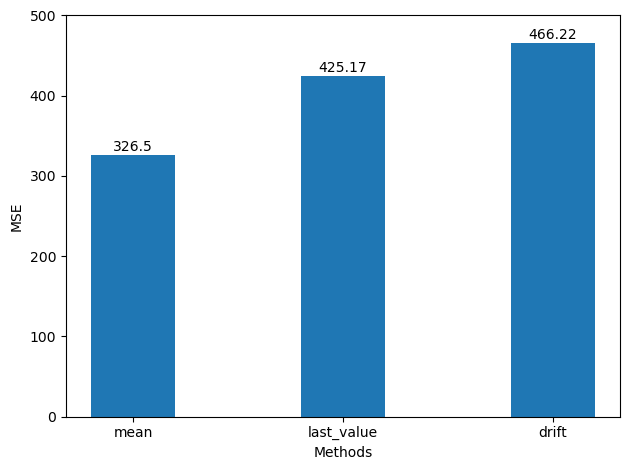

In [41]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'drift']
y = [mse_mean, mse_last, mse_drift]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 500)

for index, value in enumerate(y):
    plt.text(x=index, y=value+5, s=str(round(value, 2)), ha='center')

plt.tight_layout()

### ***MSEs of our forecasts. Clearly, the future of a random walk is unpredictable, with MSEs exceeding 300.***

## As you can see in figure, the best forecast was obtained by predicting the historical mean, and yet the MSE exceeds 300. This is an extremely high value considering that our simulated random walk does not exceed the value of 30. By now, you should be convinced that forecasting a random walk on a long horizon does not make sense. Since the future value is dependent on the past value plus a random number, the randomness portion is magnified in a long horizon where many random numbers are added over the course of many timesteps.

# ***Forecasting the next timestep (NAIVE FORCASTING)***

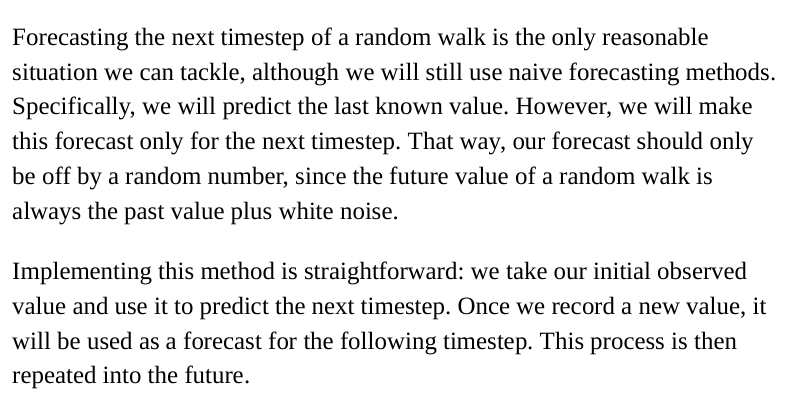
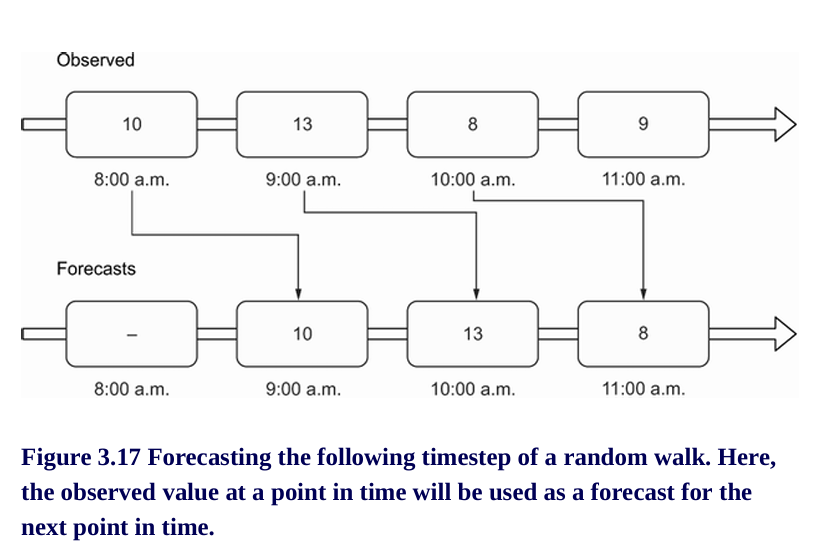

In [42]:
df_shift = df.shift(periods=1)    
df_shift.head()

,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


### **PLOTTING**

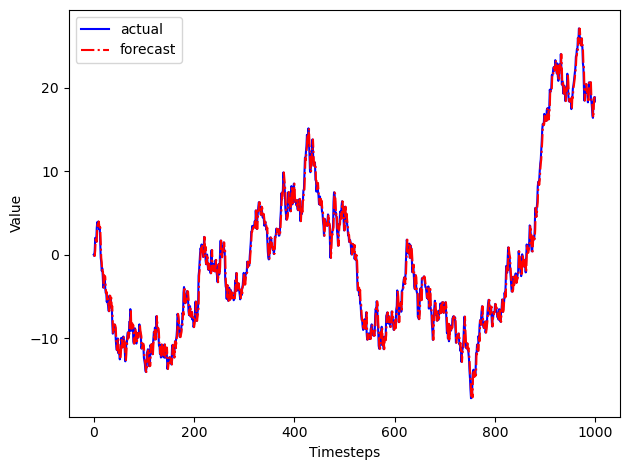

In [43]:
fig, ax = plt.subplots() 
ax.plot(df, 'b-', label='actual') 
ax.plot(df_shift, 'r-.', label='forecast') 
ax.legend(loc=2) 
ax.set_xlabel('Timesteps') 
ax.set_ylabel('Value') 
plt.tight_layout()

## **A naive forecast of the next timestep of a random walk. This plot gives the illusion of a very good model, when we are in fact only predicting the value observed at the previous timestep.**

### Calculating MSE

In [44]:
mse_one_step = mean_squared_error(test['value'], df_shift[800:])    
print(mse_one_step)

0.9256876651440581


This yields a value of 0.93, which again might lead us to think that we have
a very performant model, since the MSE is very close to 0. However, we
know that we are simply forecasting the value observed at the previous
timestep. This becomes more apparent if we zoom in on our graph.

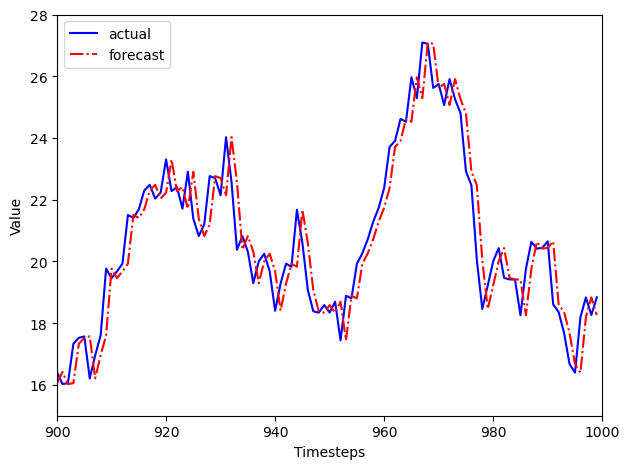

In [45]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='forecast')

ax.legend(loc=2)

ax.set_xlim(900, 1000)
ax.set_ylim(15, 28)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

Close-up on the last 100 timesteps of our random walk. Here
we can see how our forecasts are a simple shift of the original time
series.

## ***NOTE-->***  Therefore, if a random walk process must be forecast, it is better to make many short-term forecasts. That way, we do not allow for many random numbers to accumulate over time, which will degrade the quality of our forecasts in the long term. Because a random process takes random steps into the future, we cannot use statistical or deep learning techniques to fit such a process: there is nothing to learn from randomness and it cannot be predicted. Instead, we must rely on naive forecasting methods.